In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
%matplotlib inline


In [2]:
nutrition = pd.read_csv("archive (3).zip")

In [3]:
nutrition 

,restaurant,item,calories,cal_fat,total_fat,sat_fat,trans_fat,cholesterol,sodium,total_carb,fiber,sugar,protein,vit_a,vit_c,calcium,salad
0,Mcdonalds,Artisan Grilled Chicken Sandwich,380,60,7,2.0,0.0,95,1110,44,3.0,11,37.0,4.0,20.0,20.0,Other
1,Mcdonalds,Single Bacon Smokehouse Burger,840,410,45,17.0,1.5,130,1580,62,2.0,18,46.0,6.0,20.0,20.0,Other
2,Mcdonalds,Double Bacon Smokehouse Burger,1130,600,67,27.0,3.0,220,1920,63,3.0,18,70.0,10.0,20.0,50.0,Other
3,Mcdonalds,Grilled Bacon Smokehouse Chicken Sandwich,750,280,31,10.0,0.5,155,1940,62,2.0,18,55.0,6.0,25.0,20.0,Other
4,Mcdonalds,Crispy Bacon Smokehouse Chicken Sandwich,920,410,45,12.0,0.5,120,1980,81,4.0,18,46.0,6.0,20.0,20.0,Other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
510,Taco Bell,Spicy Triple Double Crunchwrap,780,340,38,10.0,0.5,50,1850,87,9.0,8,23.0,20.0,10.0,25.0,Other
511,Taco Bell,Express Taco Salad w/ Chips,580,260,29,9.0,1.0,60,1270,59,8.0,7,23.0,NaN,NaN,NaN,Other
512,Taco Bell,Fiesta Taco Salad-Beef,780,380,42,10.0,1.0,60,1340,74,11.0,7,26.0,NaN,NaN,NaN,Other
513,Taco Bell,Fiesta Taco Salad-Chicken,720,320,35,7.0,0.0,70,1260,70,8.0,8,32.0,NaN,NaN,NaN,Other


In [4]:
print(nutrition["restaurant"].unique())

['Mcdonalds' 'Chick Fil-A' 'Sonic' 'Arbys' 'Burger King' 'Dairy Queen'
 'Subway' 'Taco Bell']


In [5]:
fastfood = pd.read_csv("archive (4).zip")
fastfood

,Fast-Food Chains,U.S. Systemwide Sales (Millions - U.S Dollars),Average Sales per Unit (Thousands - U.S Dollars),Franchised Stores,Company Stores,2021 Total Units,Total Change in Units from 2020
0,Arby’s,4462,1309,2293,1116,3409,40
1,Baskin-Robbins,686,296,2317,0,2317,102
2,Bojangles,1485,1924,496,277,773,15
3,Burger King,10033,1470,7054,51,7105,24
4,Carl’s Jr.,1560,1400,1011,47,1058,-21
5,Checkers/Rally’s,931,1145,568,266,834,-13
6,Chick-fil-A,16700,6100,2650,82,2732,155
7,Chipotle,7547,2641,0,2966,2966,198
8,Church’s Chicken,776,870,731,161,892,-13
9,Culver’s,2489,3099,831,6,837,55


For my project , I will focus on calories, sodium ,sat_fat , and sugar to measure the unhealthiness.


In [12]:
Health = nutrition[['restaurant','item','calories', 'sodium', 'sat_fat','sugar']]
Health

,restaurant,item,calories,sodium,sat_fat,sugar
0,Mcdonalds,Artisan Grilled Chicken Sandwich,380,1110,2.0,11
1,Mcdonalds,Single Bacon Smokehouse Burger,840,1580,17.0,18
2,Mcdonalds,Double Bacon Smokehouse Burger,1130,1920,27.0,18
3,Mcdonalds,Grilled Bacon Smokehouse Chicken Sandwich,750,1940,10.0,18
4,Mcdonalds,Crispy Bacon Smokehouse Chicken Sandwich,920,1980,12.0,18
...,...,...,...,...,...,...
510,Taco Bell,Spicy Triple Double Crunchwrap,780,1850,10.0,8
511,Taco Bell,Express Taco Salad w/ Chips,580,1270,9.0,7
512,Taco Bell,Fiesta Taco Salad-Beef,780,1340,10.0,7
513,Taco Bell,Fiesta Taco Salad-Chicken,720,1260,7.0,8


For my project, I will focus on 2021 Total Sale Units and U.S. Systemwide Sales (Millions - U.S Dollars) to determine the popularity of the fast food chain . I also will only list ['McDonald’s', 'Chick-fil-A', 'Sonic Drive-In','Arby’s',
               'Burger King', 'Dairy Queen'] because the other data set only included them

In [17]:
restaurants = ['McDonald’s', 'Chick-fil-A', 'Sonic Drive-In','Arby’s',
               'Burger King', 'Dairy Queen']

pop_filtered = fastfood[fastfood['Fast-Food Chains'].isin(restaurants)]

print(pop_filtered)

   Fast-Food Chains  U.S. Systemwide Sales (Millions - U.S Dollars)  \
0            Arby’s                                            4462   
3       Burger King                                           10033   
6       Chick-fil-A                                           16700   
10      Dairy Queen                                            4494   
28       McDonald’s                                           45960   
39   Sonic Drive-In                                            5835   

    Average Sales per Unit (Thousands - U.S Dollars)  Franchised Stores  \
0                                               1309               2293   
3                                               1470               7054   
6                                               6100               2650   
10                                              1036               4337   
28                                              3420              12775   
39                                              1643

In [19]:
pop= pop_filtered[['Fast-Food Chains','U.S. Systemwide Sales (Millions - U.S Dollars)', '2021 Total Units' ]]
pop

,Fast-Food Chains,U.S. Systemwide Sales (Millions - U.S Dollars),2021 Total Units
0,Arby’s,4462,3409
3,Burger King,10033,7105
6,Chick-fil-A,16700,2732
10,Dairy Queen,4494,4339
28,McDonald’s,45960,13438
39,Sonic Drive-In,5835,3552


In [22]:
avg_calories = nutrition.groupby("restaurant")["calories"].mean().sort_values(ascending=False)

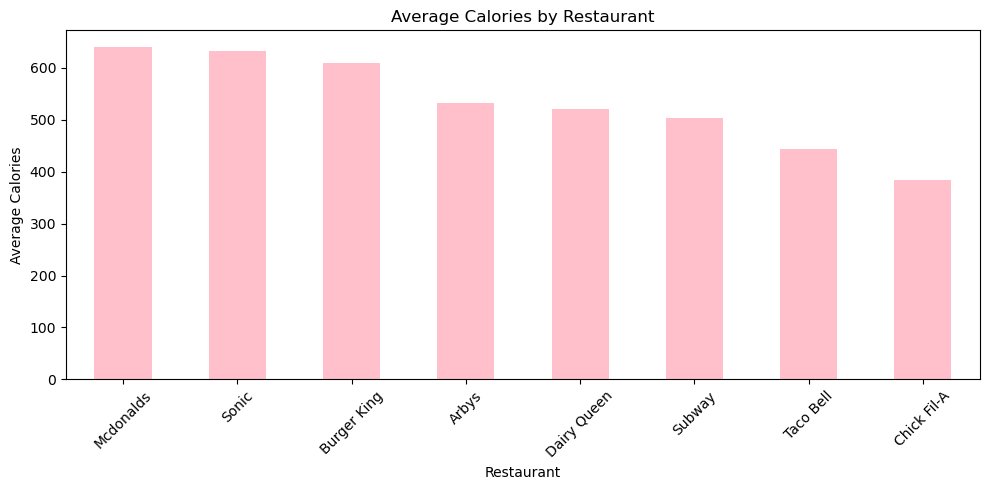

In [24]:
plt.figure(figsize=(10,5))
avg_calories.plot(kind="bar", color = 'pink')

plt.xlabel("Restaurant")
plt.ylabel("Average Calories")
plt.title("Average Calories by Restaurant")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [82]:
#more items= higher calories 
#break down to individual items 
#scale by the average by the number of items
#grid lines 

In [27]:
avg_sod = nutrition.groupby("restaurant")["sodium"].mean().sort_values(ascending=False)

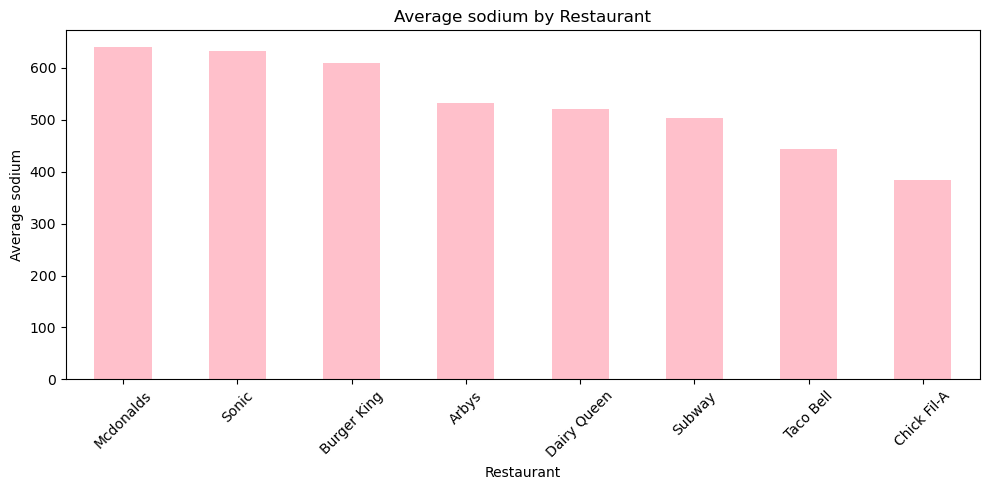

In [29]:
plt.figure(figsize=(10,5))
avg_calories.plot(kind="bar", color = 'pink')

plt.xlabel("Restaurant")
plt.ylabel("Average sodium")
plt.title("Average sodium by Restaurant")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

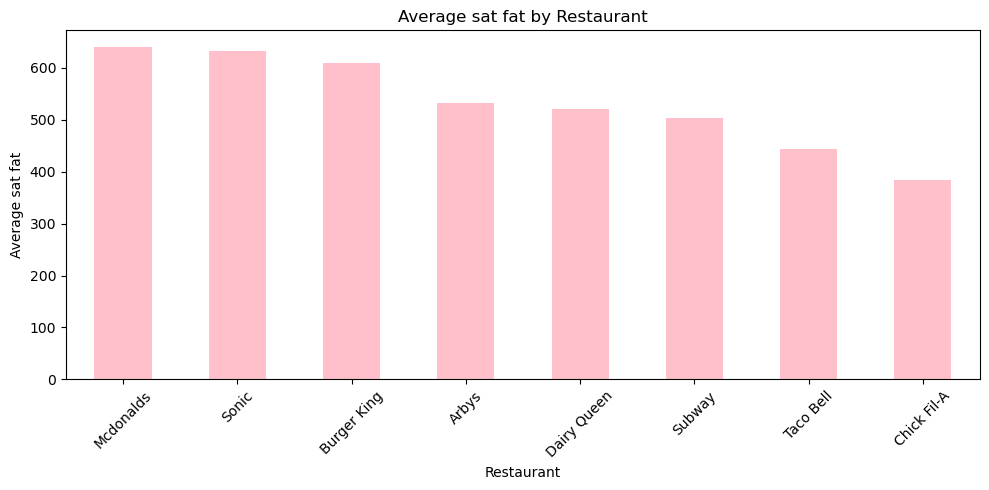

In [31]:
avg_sod = nutrition.groupby("restaurant")["sat_fat"].mean().sort_values(ascending=False)
plt.figure(figsize=(10,5))
avg_calories.plot(kind="bar", color = 'pink')

plt.xlabel("Restaurant")
plt.ylabel("Average sat fat")
plt.title("Average sat fat by Restaurant")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

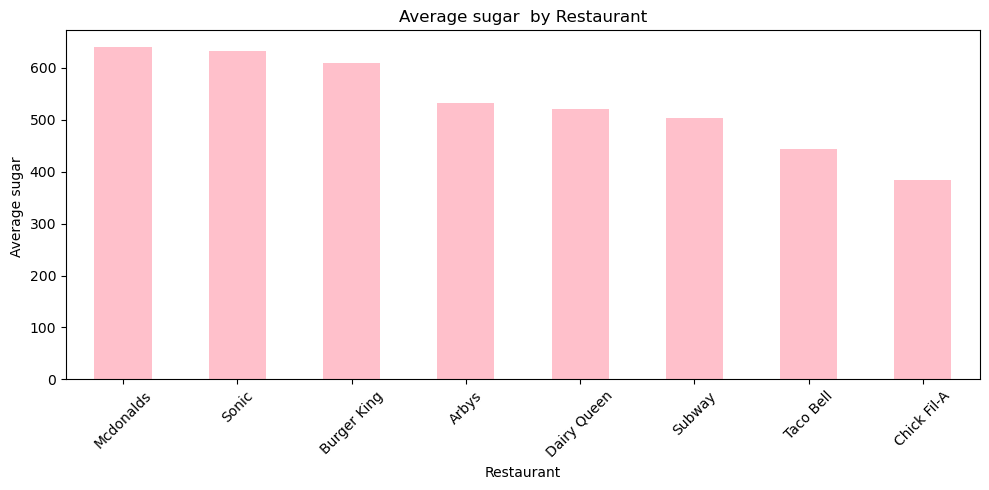

In [33]:
avg_sod = nutrition.groupby("restaurant")["sugar"].mean().sort_values(ascending=False)
plt.figure(figsize=(10,5))
avg_calories.plot(kind="bar", color = 'pink')

plt.xlabel("Restaurant")
plt.ylabel("Average sugar ")
plt.title("Average sugar  by Restaurant")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [86]:
#heat map for different restraunts 
#violin plots or box plots

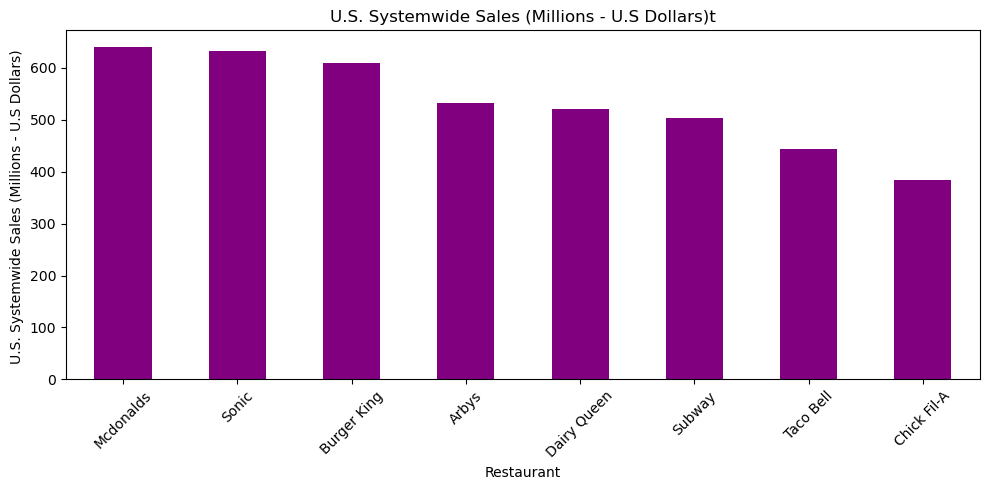

In [36]:
avg = pop.groupby("Fast-Food Chains")["U.S. Systemwide Sales (Millions - U.S Dollars)"].mean().sort_values(ascending=False)
plt.figure(figsize=(10,5))
avg_calories.plot(kind="bar", color = 'purple')

plt.xlabel("Restaurant")
plt.ylabel("U.S. Systemwide Sales (Millions - U.S Dollars) ")
plt.title("U.S. Systemwide Sales (Millions - U.S Dollars)t")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
#scale it by restaurants , 

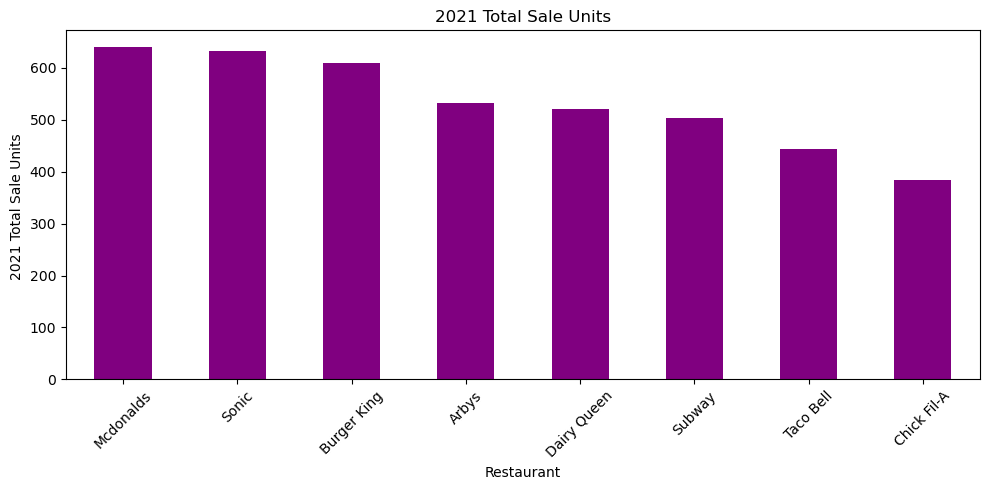

In [38]:
avg = pop.groupby("Fast-Food Chains")["2021 Total Units"].mean().sort_values(ascending=False)
plt.figure(figsize=(10,5))
avg_calories.plot(kind="bar", color = 'purple')

plt.xlabel("Restaurant")
plt.ylabel("2021 Total Sale Units ")
plt.title("2021 Total Sale Units")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

combined

In [67]:
pop = pop.rename(columns={"Fast-Food Chains": "restaurant"})

In [69]:
pop

,restaurant,U.S. Systemwide Sales (Millions - U.S Dollars),2021 Total Units
0,Arby’s,4462,3409
3,Burger King,10033,7105
6,Chick-fil-A,16700,2732
10,Dairy Queen,4494,4339
28,McDonald’s,45960,13438
39,Sonic Drive-In,5835,3552


In [71]:
combined = pd.merge(Health, pop, on= "restaurant", how="inner")

In [91]:
print(combined.head())
print(combined.shape)

    restaurant                          item  calories  sodium  sat_fat  \
0  Burger King       American Brewhouse King      1550    1820     47.0   
1  Burger King  Bacon & Swiss Sourdough King      1000    1320     24.0   
2  Burger King            Bacon Cheeseburger       330     830      7.0   
3  Burger King     Bacon Cheeseburger Deluxe       290     720      6.0   
4  Burger King                    Bacon King      1040    1900     28.0   

   sugar  U.S. Systemwide Sales (Millions - U.S Dollars)  2021 Total Units  
0      7                                           10033              7105  
1      8                                           10033              7105  
2      7                                           10033              7105  
3      7                                           10033              7105  
4     10                                           10033              7105  
(112, 8)


Feedback: 
Group members :
Khan Ishmail,Joshi Sanika, Hodgson Sophie, Haitsuka Shota , Grimes Brandon
It was suggested to scale my dataset because for example, Mcdonalds will have more items than dairy queen , so I need to scale it to show the true value.
It was also suggested to use violin or histograms to cleary show the data.
